# **SimpleCorridor - v0**

### 1. Environment Setup


**SimpleCorridor - v0** -provides costum reinforcment learning algorithm, created using the OPENAI gym.

- Task: Go fro one end of a straight corridor to the other.

#### 1.1 Installations

**Gymnasium** - modern version of OpenAI Gym.

*   Neccessary when creating a costumized OpenAI Gym-compatible environment.


**Stable Baselines3** - a library that pre-built renforcment learning algorithms. (*Later PPO*)
*   It is going to be used to train the agent through reinforcement learning.

**Pyglet** - python library for graphical user interface rendering.
(*Questionable if it ever was necessary*)



In [ ]:
# To intall the dependencies you can either uncomment and run this cell, or more efficiently install via requirements.txt.
#!pip install stable_baselines3
#!pip install pyglet
#!pip install moviepy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.1 MB/s eta 0:00:00


#### 1.2 Imports

In [2]:
import gymnasium as gym
from gymnasium import spaces          # defining different spaces (action/observation space)
import os                             # access to file paths in OS
from gym.wrappers.record_video import RecordVideo

from stable_baselines3 import PPO     # algorithm for training
from stable_baselines3.common.monitor import Monitor                       # record punishments/rewards
from stable_baselines3.common.results_plotter import load_results, ts2xy   # load results for plotting
from stable_baselines3.common.env_util import make_vec_env
import numpy as np
import matplotlib.pyplot as plt


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

### 2. Custom Gym Enviroment (*SimpleCorridorEnv Class*)

In [3]:
class SimpleCorridorEnv(gym.Env):
    def __init__(self, corridor_length=10):
        super(SimpleCorridorEnv, self).__init__()
        self.corridor_length = corridor_length
        self.current_pos = 0                    # agents start position

        # Define action and observation space
        self.action_space = spaces.Discrete(2)  # movements: 0=Left/ 1=Right
        self.observation_space = spaces.Discrete(corridor_length)

    # At the begining of each episode environment is reset
    def reset(self, seed=None, options=None):
        self.current_pos = 0                     # returning to original position
        return self.current_pos, {}

    # Actions and updates
    def step(self, action):
        if action == 1:
            self.current_pos = min(self.current_pos + 1, self.corridor_length - 1)
        else:                                    # action == 0
            self.current_pos = max(self.current_pos - 1, 0)

        # Check if reached goal
        terminated = self.current_pos == self.corridor_length - 1
        reward = -0.1
        if terminated:
          reward=1.0                             # only if the goal is reached

        truncated = False

        return self.current_pos, reward, terminated, truncated, {}

    # Visual display of the agent's movements in the env.
    def render(self):
      corridor = ['_'] * self.corridor_length

      if self.current_pos == self.corridor_length - 1:
          corridor[self.current_pos] = 'AG'
      else:
          corridor[self.current_pos] = 'A'
          corridor[-1] = 'G'

      print(f"Agent's position: {self.current_pos}: {''.join(corridor)}")


# Registering the environment in GYM
gym.register(
    id="SimpleCorridor-v0",
    entry_point="__main__:SimpleCorridorEnv",
    kwargs={"corridor_length": 10}
)


### 3. Testing w/o Trained Agent

In [ ]:
env = gym.make("SimpleCorridor-v0")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)              # how can agent move

print("\n"+"="*50)
print("Performance Evaluation - Untrained Agent")
print("="*50)

# Test the environment
obs, _ = env.reset()
print("Initial position:", obs)
for _ in range(10):
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    print(f"Action: {action}, New position: {obs}, Reward: {reward}, Done: {done}")
    env.render()
    if done:
      print("The goal was reached!")
      break

Observation space: Discrete(10)
Action space: Discrete(2)

Performance Evaluation - Untrained Agent
Initial position: 0
Action: 1, New position: 1, Reward: -0.1, Done: False
Agent's position: 1: _A_______G
Action: 0, New position: 0, Reward: -0.1, Done: False
Agent's position: 0: A________G
Action: 0, New position: 0, Reward: -0.1, Done: False
Agent's position: 0: A________G
Action: 1, New position: 1, Reward: -0.1, Done: False
Agent's position: 1: _A_______G
Action: 1, New position: 2, Reward: -0.1, Done: False
Agent's position: 2: __A______G
Action: 1, New position: 3, Reward: -0.1, Done: False
Agent's position: 3: ___A_____G
Action: 0, New position: 2, Reward: -0.1, Done: False
Agent's position: 2: __A______G
Action: 0, New position: 1, Reward: -0.1, Done: False
Agent's position: 1: _A_______G
Action: 0, New position: 0, Reward: -0.1, Done: False
Agent's position: 0: A________G
Action: 0, New position: 0, Reward: -0.1, Done: False
Agent's position: 0: A________G


###4. Training the Agent

Here I created a folder called *logs*, which will record training parameters/logs. This will be later applied to test with the trained agent.

In [4]:
log_dir="./logs/"
os.makedirs(log_dir, exist_ok=True)

env=gym.make("SimpleCorridor-v0")
env=Monitor(env,log_dir)

**Agent** - a program that interacts with the environment, makes decision and learns thorugh reinforced learning . (So, penalties and rewards).


**PPO Agent** - (*Proximal Policy Optimization*) - reinforcment learning algorithm used to train agent to improve in their interactions with the enironment and the prosibility of reaching a goal fast.


**MlpPolicy** - using a multilayer perceptron to learn how to interact.


The goal is that the PPO agent, after training, knows how to interact. (*e.g. interacting with teh SimpleCorridor - v0*)

In [5]:
print("\n"+"="*50)
print("Performance Evaluatio - Trained Agent")
print("="*50)

model=PPO("MlpPolicy", env, verbose=1)            # creating a model/agent
model.learn(total_timesteps=5000)


Performance Evaluatio - Trained Agent
Using cuda device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 103      |
|    ep_rew_mean     | -9.17    |
| time/              |          |
|    fps             | 536      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 50.9        |
|    ep_rew_mean          | -3.99       |
| time/                   |             |
|    fps                  | 458         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.019804195 |
|    clip_fraction        | 0.212       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.678      |
|    explained_variance   | -0.0288     |
|    learning_rate        | 0.

In [6]:
def plot_rewards(log_folder):
  x, y=ts2xy(load_results(log_folder), 'timesteps')
  plt.figure(figsize=(10,5))
  plt.plot(x,y)
  plt.xlabel("Timesteps")
  plt.ylabel("Reward per Episode")
  plt.title("Reward versus Timesteps")
  plt.grid()
  plt.legend()
  plt.show

/tmp/ipykernel_3624/379478721.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


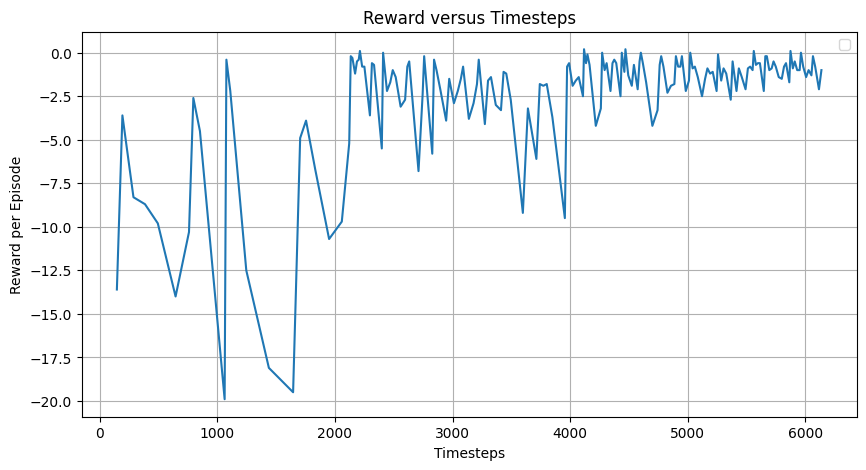

In [7]:
plot_rewards(log_dir)

In [8]:
eval_env=gym.make("SimpleCorridor-v0")
obs, _=env.reset()


In [9]:
for step in range(20):
  action,_=model.predict(obs)
  obs, reward, done, truncated, _=env.step(action)
  print(f"Action: {action}, New position: {obs}, Reward: {reward}, Done: {done}")
  env.render()
  if done or truncated:
    print("Congratulations the goal was reached!")
    break

Action: 1, New position: 1, Reward: -0.1, Done: False
Agent's position: 1: _A_______G
Action: 1, New position: 2, Reward: -0.1, Done: False
Agent's position: 2: __A______G
Action: 1, New position: 3, Reward: -0.1, Done: False
Agent's position: 3: ___A_____G
Action: 1, New position: 4, Reward: -0.1, Done: False
Agent's position: 4: ____A____G
Action: 1, New position: 5, Reward: -0.1, Done: False
Agent's position: 5: _____A___G
Action: 1, New position: 6, Reward: -0.1, Done: False
Agent's position: 6: ______A__G
Action: 1, New position: 7, Reward: -0.1, Done: False
Agent's position: 7: _______A_G
Action: 1, New position: 8, Reward: -0.1, Done: False
Agent's position: 8: ________AG
Action: 1, New position: 9, Reward: 1.0, Done: True
Agent's position: 9: _________AG
Congratulations the goal was reached!


###5. Testing the Environment & Untrained Dataset

In [10]:
print("\n"+"="*50)
print("Performance Evaluation - Untrained Agent")
print("="*50)

successes =0
total_episodes=100
total_steps=0

for episode in range(total_episodes):
  obs,_ =env.reset()
  episode_steps=0

  for step in range (50):
    action,_=model.predict(obs)
    obs, reward, done, truncated,_=env.step(action)
    episode_steps+=1

    if done or truncated:
      if done:
        successes+=1
        break
  total_steps+=episode_steps

success_rate=successes/total_episodes
average_steps=total_steps/total_episodes


print(f"Success Rate: {success_rate:.2%}")
print(f"Average Steps per Episode: {average_steps:.3f}")
print(f"Total Episodes: {total_episodes}")
print(f" Successful Episodes: {successes}")


Performance Evaluation - Untrained Agent
Success Rate: 100.00%
Average Steps per Episode: 13.180
Total Episodes: 100
 Successful Episodes: 100


In [ ]:
model.save("PPOSimpleCorridor")

**Conclussion**

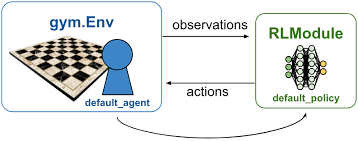



*   **Environment:** SimpleCorridor-v0  - OpenAI GYM
*   **Agent:** PPO Agent (*Proximal Policy Optimization*)
*   **Neural Network Model:** MLP (*Multi-Layer Perceptron*) w/ fully connected feed-forward layers.
*   **Reward:** Only positive when the goal is reached.



#**6. Recording and Generating the Video**

In [11]:
import gymnasium as gym
import numpy as np
import imageio
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import base64

# Method 1: Using imageio to create MP4 video
def create_video_imageio(env, agent_or_policy, filename="agent_video.mp4", num_episodes=5, fps=30):
    """
    Create a video of the agent playing the game using imageio

    Args:
        env: The gymnasium environment
        agent_or_policy: Either a trained agent object or a policy function
        filename: Output video filename
        num_episodes: Number of episodes to record
        fps: Frames per second
    """
    frames = []

    for episode in range(num_episodes):
        obs, info = env.reset()
        done = False
        truncated = False
        episode_frames = []

        while not (done or truncated):
            # Get frame from environment
            frame = env.render()
            episode_frames.append(frame)

            # Get action from your trained agent
            # Replace this with your agent's action selection method
            if hasattr(agent_or_policy, 'predict'):
                # For stable-baselines3 agents
                action, _ = agent_or_policy.predict(obs)
            elif hasattr(agent_or_policy, 'act'):
                # For custom agents with act method
                action = agent_or_policy.act(obs)
            elif callable(agent_or_policy):
                # For policy functions
                action = agent_or_policy(obs)
            else:
                # Fallback to random action
                action = env.action_space.sample()

            obs, reward, done, truncated, info = env.step(action)

        frames.extend(episode_frames)
        print(f"Episode {episode + 1} completed with {len(episode_frames)} frames")

    # Save video
    imageio.mimsave(filename, frames, fps=fps)
    print(f"Video saved as {filename}")
    return filename

# Method 2: Using gym's video wrapper
def create_video_gym_wrapper(env_name, agent_or_policy, video_folder="./videos", num_episodes=5):
    """
    Create video using gym's video recording wrapper
    """
    from gym.wrappers import RecordVideo

    # Create environment with video recording
    env = gym.make(env_name)
    env = RecordVideo(env, video_folder=video_folder, episode_trigger=lambda x: True)

    for episode in range(num_episodes):
        obs = env.reset()
        done = False

        while not done:
            # Get action from your trained agent
            if hasattr(agent_or_policy, 'predict'):
                action, _ = agent_or_policy.predict(obs)
            elif hasattr(agent_or_policy, 'act'):
                action = agent_or_policy.act(obs)
            elif callable(agent_or_policy):
                action = agent_or_policy(obs)
            else:
                action = env.action_space.sample()

            obs, reward, done, info = env.step(action)

    env.close()
    print(f"Videos saved in {video_folder}")

# Method 3: Display video in Colab
def display_video_in_colab(video_path):
    """
    Display video directly in Colab notebook
    """
    from IPython.display import HTML
    import base64

    video = open(video_path, 'rb').read()
    video_encoded = base64.b64encode(video).decode('ascii')

    video_html = f'''
    <video width="600" controls>
        <source src="data:video/mp4;base64,{video_encoded}" type="video/mp4">
    </video>
    '''

    display(HTML(video_html))

# Example usage:
# Assuming you have a trained agent called 'model'

# Create environment
env = gym.make('SimpleCorridor-v0', render_mode="rgb_array")

# Example 1: If you're using stable-baselines3
"""
from stable_baselines3 import PPO

# Load your trained model
model = PPO.load("path_to_your_model")

# Create video
video_file = create_video_imageio(env, model, "simplecorridor_agent.mp4", num_episodes=3)

# Display in Colab
display_video_in_colab(video_file)
"""

# Example 2: If you have a custom policy function
def your_policy_function(observation):
    # Replace this with your trained policy
    # This is just a placeholder
    return env.action_space.sample()

# Create video with custom policy
video_file = create_video_imageio(env, your_policy_function, "simplecorridor_custom.mp4", num_episodes=3)

# Display in Colab
display_video_in_colab(video_file)

# Example 3: If you have a custom agent class
class YourAgent:
    def __init__(self, model_path=None):
        # Load your trained model here
        pass

    def predict(self, observation):
        # Your prediction logic here
        # Return action and optional info
        action = env.action_space.sample()  # Replace with actual prediction
        return action, None

    def act(self, observation):
        # Alternative method name
        return self.predict(observation)[0]

# Use custom agent
# agent = YourAgent("path_to_your_model")
# video_file = create_video_imageio(env, agent, "simplecorridor_agent.mp4", num_episodes=3)
# display_video_in_colab(video_file)

# Close environment
env.close()

print("Video generation setup complete!")
print("Replace the agent/policy placeholders with your actual trained model.")

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


TypeError: SimpleCorridorEnv.__init__() got an unexpected keyword argument 'render_mode' was raised from the environment creator for SimpleCorridor-v0 with kwargs ({'corridor_length': 10, 'render_mode': 'rgb_array'})